# =========================================
# EJERCICIO 3 - CLUSTERING
# =========================================

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# Cargar dataset
cluster_df = pd.read_csv("https://raw.githubusercontent.com/MendezBy02/Parcial4-Abel-Antonio-Escobar-Mendez-25-1449-2022/refs/heads/main/archivos/clave_B_agrupacion.csv")

# Mostrar primeras filas
cluster_df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,B-R0196,35,962,3.08,42.02,4.95,6,1
1,B-R0031,18,534,3.36,47.80,6.81,2,14
2,B-R0059,24,408,2.24,68.25,5.75,0,1
3,B-R0204,48,1250,4.52,61.06,2.54,12,6
4,B-R0103,35,1043,6.96,78.62,7.37,0,1


In [5]:
# Informacion general
cluster_df.info()

# Estadisticas
cluster_df.describe()

# Valores nulos
cluster_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       234 non-null    object 
 1   edad              234 non-null    int64  
 2   ingresos          234 non-null    int64  
 3   frecuencia_uso    234 non-null    float64
 4   gasto_promedio    234 non-null    float64
 5   satisfaccion      233 non-null    float64
 6   reclamos          234 non-null    int64  
 7   antiguedad_meses  234 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 14.8+ KB


,0
registro_id,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,1
reclamos,0
antiguedad_meses,0


In [6]:
# Variables numericas
X = cluster_df.select_dtypes(include=np.number)

# Mostrar columnas
X.columns

Index(['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion',
       'reclamos', 'antiguedad_meses'],
      dtype='object')

Explicación:

Se seleccionan variables numéricas debido a que el algoritmo K-Means trabaja con datos cuantitativos para identificar grupos similares.

In [7]:
# Escalar datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Explicación

Se normalizan los datos para evitar que variables con valores más grandes tengan mayor influencia en el algoritmo de agrupación.

In [11]:
inertia = []

# Impute missing values in X before scaling
X_imputed = X.fillna(X.mean())
X_scaled = scaler.fit_transform(X_imputed)

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

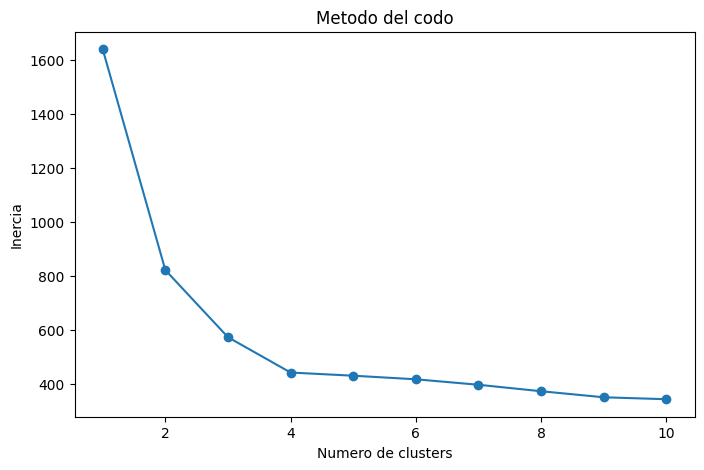

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Metodo del codo")
plt.xlabel("Numero de clusters")
plt.ylabel("Inercia")

plt.show()

La curva hace el “codo” aproximadamente en: K = 4
Porque despues de 4 clusters la reduccion de inercia ya es mucho menor.

In [13]:
# Aplicar K-Means con 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Crear clusters
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar resultados
cluster_df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,Cluster
0,B-R0196,35,962,3.08,42.02,4.95,6,1,3
1,B-R0031,18,534,3.36,47.80,6.81,2,14,2
2,B-R0059,24,408,2.24,68.25,5.75,0,1,2
3,B-R0204,48,1250,4.52,61.06,2.54,12,6,3
4,B-R0103,35,1043,6.96,78.62,7.37,0,1,0


Explicación:

Se aplicó el algoritmo K-Means utilizando 4 clusters definidos mediante el método del codo. El objetivo es agrupar clientes con características similares.

In [14]:
# Cantidad de clientes por cluster
cluster_df['Cluster'].value_counts()

,count
Cluster,
0,67
2,59
1,57
3,51


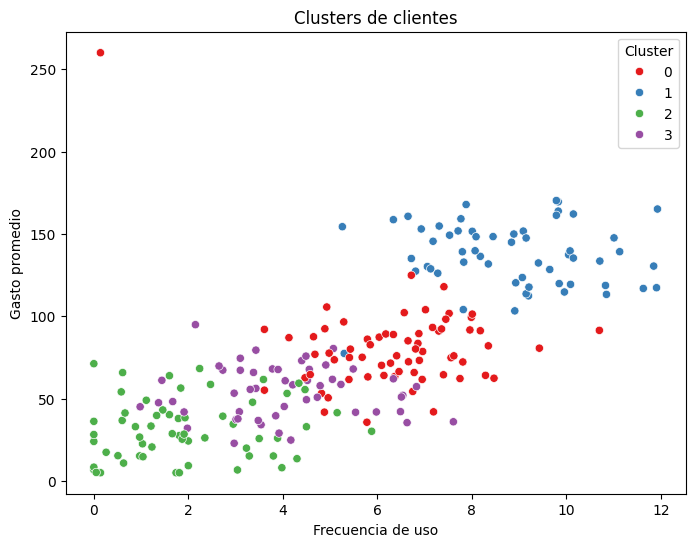

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['frecuencia_uso'],
    y=cluster_df['gasto_promedio'],
    hue=cluster_df['Cluster'],
    palette='Set1'
)

plt.title("Clusters de clientes")
plt.xlabel("Frecuencia de uso")
plt.ylabel("Gasto promedio")

plt.show()

Explicación:

El gráfico permite visualizar cómo se distribuyen los clientes según su frecuencia de compra y consumo total, diferenciando cada grupo mediante colores.

In [17]:
# Promedios por cluster
cluster_df.groupby('Cluster').mean(numeric_only=True)

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
Cluster,,,,,,,
0,33.835821,897.955224,6.366866,81.179552,8.113433,1.134328,17.388060
1,47.350877,1567.631579,8.848772,137.424561,8.748036,0.649123,36.894737
2,24.220339,533.745763,1.965763,31.420847,5.951695,3.067797,6.932203
3,38.254902,791.647059,4.055882,54.084118,4.470784,5.078431,11.333333


In [18]:
# Guardar dataset final
cluster_df.to_csv(
    'dataset_final_clusters.csv',
    index=False
)

#Interpretación de clusters

1. Cluster 0
Este grupo está compuesto por clientes con frecuencia de uso media, buen nivel de satisfacción y gasto promedio moderado. Representan clientes relativamente estables que pueden mantenerse mediante promociones y programas de fidelización.

2. Cluster 1
Los clientes de este grupo presentan el mayor gasto promedio, alta frecuencia de uso y altos ingresos. Además, muestran buena satisfacción y pocos reclamos. Este segmento representa los clientes más valiosos para la empresa.

3. Cluster 2
Este cluster está conformado por clientes jóvenes con bajo gasto promedio y poca frecuencia de uso. Aunque presentan satisfacción moderada, requieren estrategias para aumentar su participación y consumo.

4. Cluster 3
Los clientes de este grupo muestran bajos niveles de satisfacción y una alta cantidad de reclamos. También presentan un gasto promedio bajo. Este segmento requiere atención prioritaria para mejorar la experiencia del cliente.

#Acciones de negocio para cada cluster

Cluster 0
Implementar programas de fidelización y descuentos personalizados para mantener la frecuencia de compra.

Cluster 1
Ofrecer beneficios exclusivos, promociones premium y atención personalizada para retener a los clientes de alto valor.

Cluster 2
Diseñar campañas de marketing dirigidas a clientes jóvenes para incrementar el uso y consumo de productos.

Cluster 3
Mejorar el servicio al cliente y reducir tiempos de respuesta para disminuir reclamos y aumentar la satisfacción.

#Conclusión

El análisis de clustering permitió segmentar a los clientes en grupos con características similares utilizando el algoritmo K-Means. Se identificaron clientes de alto valor, clientes con bajo nivel de consumo y clientes con problemas de satisfacción. Esta segmentación permite a la empresa crear estrategias diferenciadas para mejorar la experiencia del cliente, aumentar las ventas y optimizar recursos comerciales.